In [1]:
# Setup: imports and helper functions
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Helper to show dataframe nicely in environments that support it
try:
    from caas_jupyter_tools import display_dataframe_to_user
    def show_df(name, df):
        display_dataframe_to_user(name, df)
except Exception:
    def show_df(name, df):
        print(f"=== {name} (shape={df.shape}) ===")
        display(df.head())

# Matplotlib settings: each plot will be its own figure (no seaborn used)
plt.rcParams['figure.figsize'] = (8,5)


In [2]:
# Data loading
local_path = "data/diabetes.csv"  # put your PIMA CSV here
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"Loaded local CSV: {local_path}")
else:
    # Fallback: load sklearn diabetes dataset (note: this is a regression dataset, different features)
    from sklearn.datasets import load_diabetes
    skl = load_diabetes(as_frame=True)
    df = skl.frame
    # convert target to a binary label for demo (median split) — THIS IS ONLY FOR DEMO PURPOSES
    df['target_binary_demo'] = (df['target'] > df['target'].median()).astype(int)
    print("Local CSV not found. Loaded sklearn.datasets.load_diabetes as a fallback (regression dataset).")
    print("A binary target column 'target_binary_demo' was created by median-splitting the original target for demo.")

show_df("Initial dataframe sample", df)
print('\nColumns:', list(df.columns))
print('\nShape:', df.shape)


Local CSV not found. Loaded sklearn.datasets.load_diabetes as a fallback (regression dataset).
A binary target column 'target_binary_demo' was created by median-splitting the original target for demo.
=== Initial dataframe sample (shape=(442, 12)) ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,target_binary_demo
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0,0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0,0



Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target', 'target_binary_demo']

Shape: (442, 12)


In [3]:
# Quick overview: info, missing values, basic stats
print("Data types and non-null counts:\n")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nBasic descriptive statistics:")
show_df("Describe (numeric)", df.describe())


Data types and non-null counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 442 non-null    float64
 1   sex                 442 non-null    float64
 2   bmi                 442 non-null    float64
 3   bp                  442 non-null    float64
 4   s1                  442 non-null    float64
 5   s2                  442 non-null    float64
 6   s3                  442 non-null    float64
 7   s4                  442 non-null    float64
 8   s5                  442 non-null    float64
 9   s6                  442 non-null    float64
 10  target              442 non-null    float64
 11  target_binary_demo  442 non-null    int32  
dtypes: float64(11), int32(1)
memory usage: 39.8 KB
None

Missing values per column:
age                   0
sex                   0
bmi                   0
bp                 

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,target_binary_demo
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484,0.500000
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005,0.500567
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000,0.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000,0.000000


In [4]:
# Data cleaning suggestions & handle zeros-as-missing (for PIMA style datasets)
# PIMA dataset uses zeros for some features where zero is invalid (e.g., Glucose, BloodPressure, SkinThickness, Insulin, BMI)
# We'll detect suspicious zero columns if they exist and treat zeros as missing for them.
suspect_zero_cols = []
for col in df.columns:
    # only consider numeric cols
    if pd.api.types.is_numeric_dtype(df[col]):
        num_zeros = (df[col] == 0).sum()
        pct_zeros = num_zeros / len(df)
        if pct_zeros > 0 and pct_zeros < 0.5:
            suspect_zero_cols.append((col, num_zeros, pct_zeros))
if suspect_zero_cols:
    print("Columns with non-trivial zero counts (potentially missing values represented as 0):")
    for col, nz, pz in suspect_zero_cols:
        print(f" - {col}: zeros={nz} ({pz:.2%})")
else:
    print("No suspicious zero-containing numeric columns detected (or dataset different).")

# Imputation plan: use median imputation for numeric features with missing values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

print("\nAfter imputation, missing counts:")
print(df.isnull().sum())


No suspicious zero-containing numeric columns detected (or dataset different).

After imputation, missing counts:
age                   0
sex                   0
bmi                   0
bp                    0
s1                    0
s2                    0
s3                    0
s4                    0
s5                    0
s6                    0
target                0
target_binary_demo    0
dtype: int64


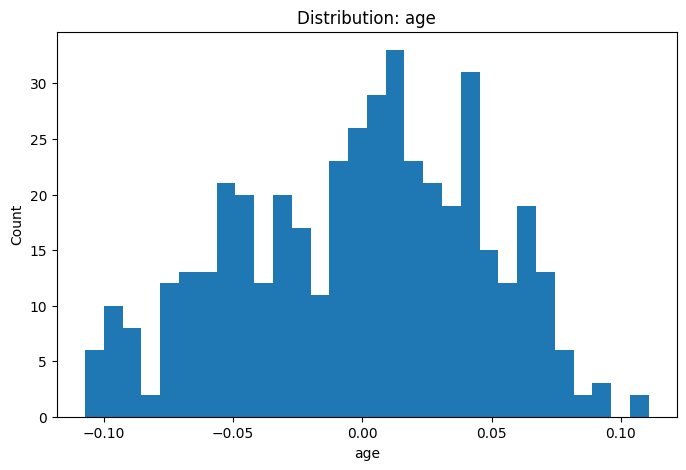

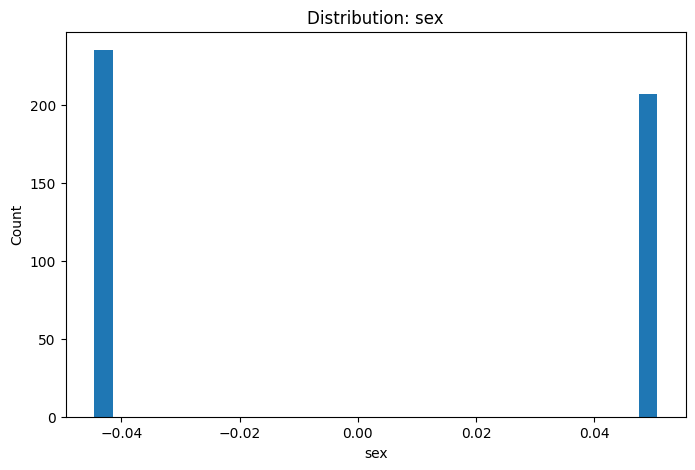

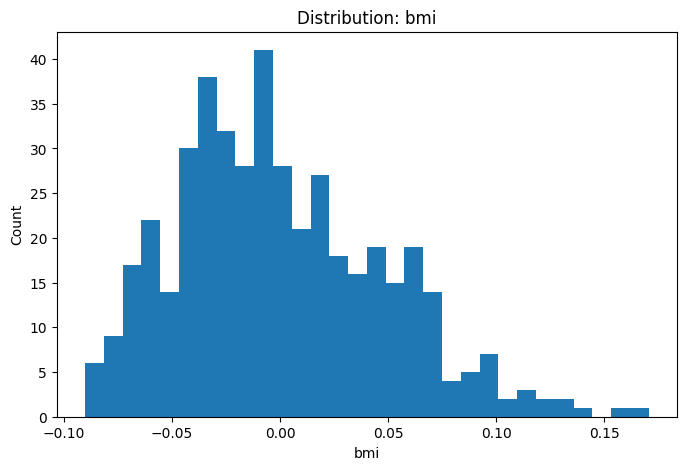

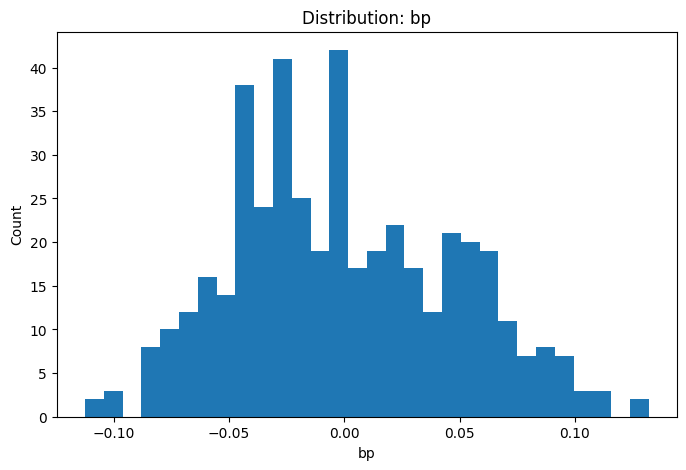

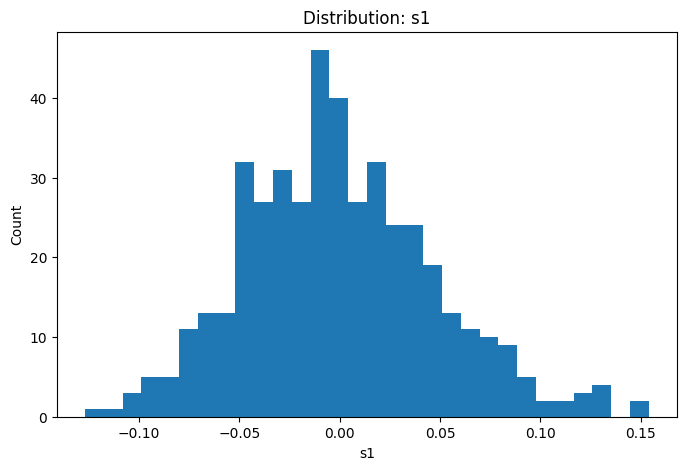

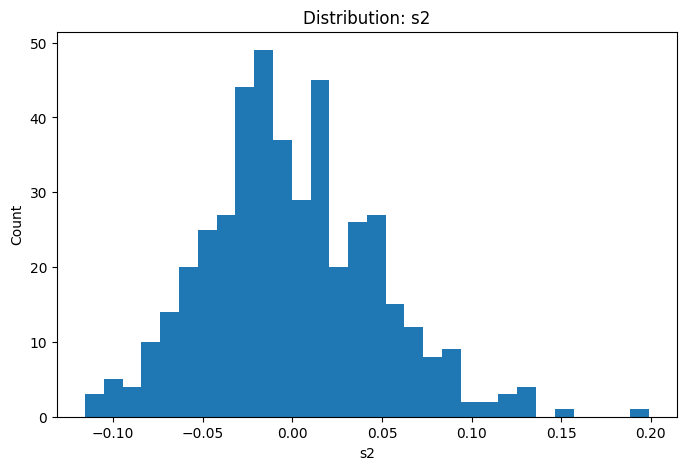

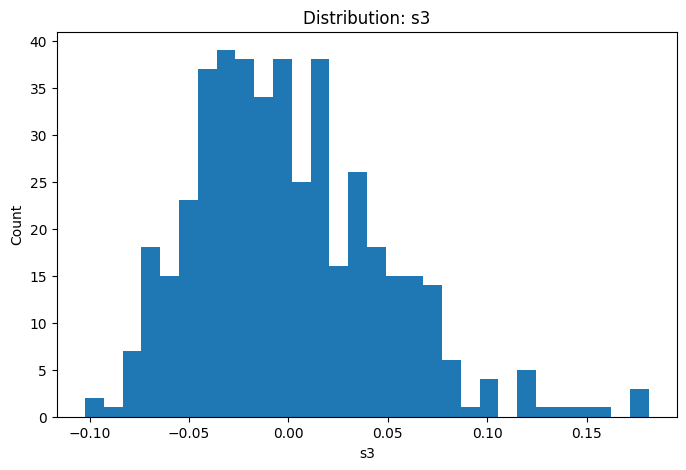

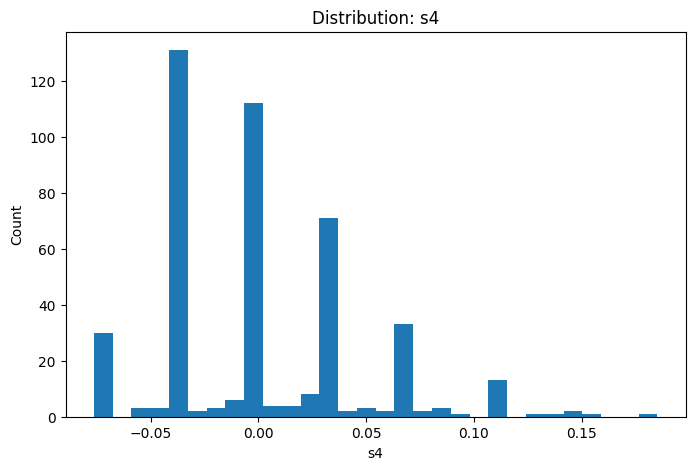

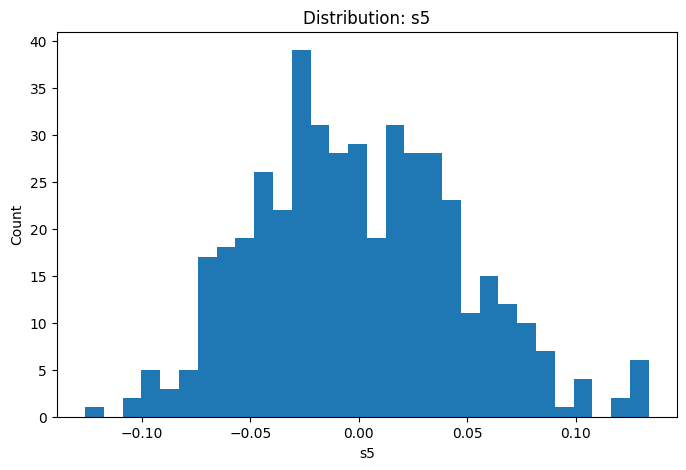

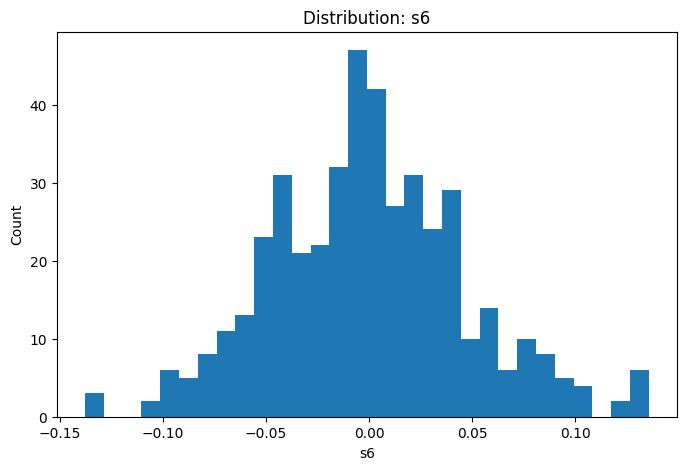

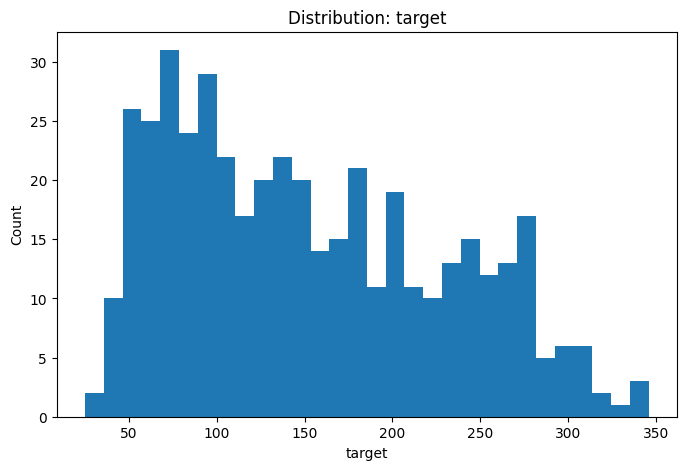

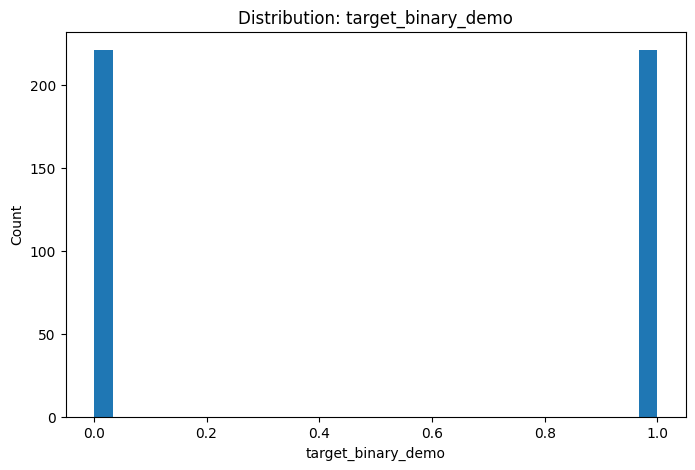

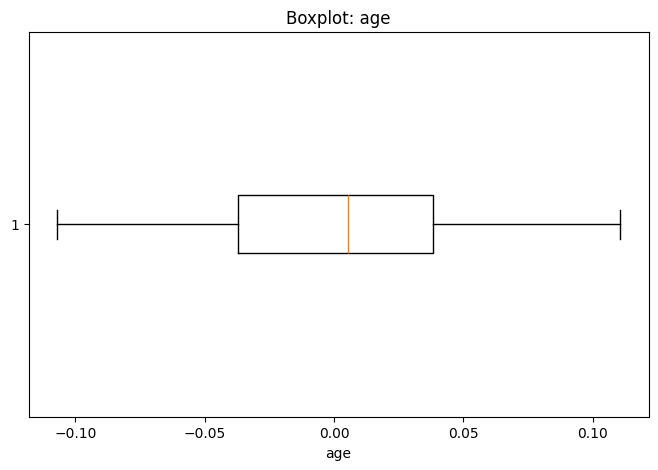

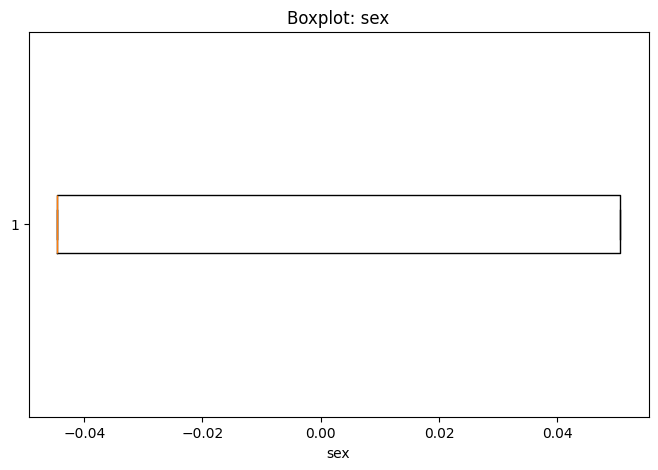

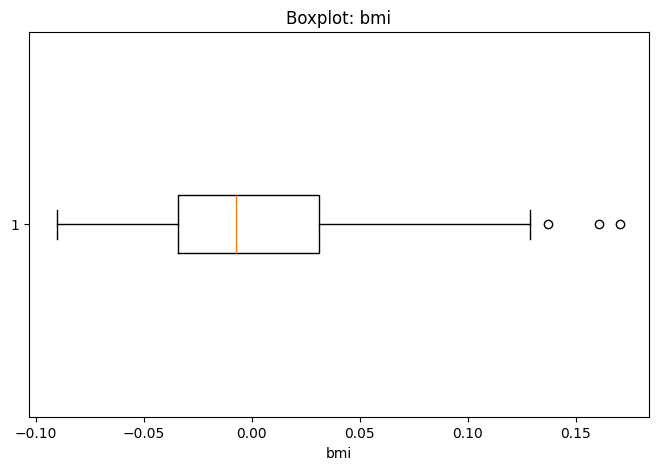

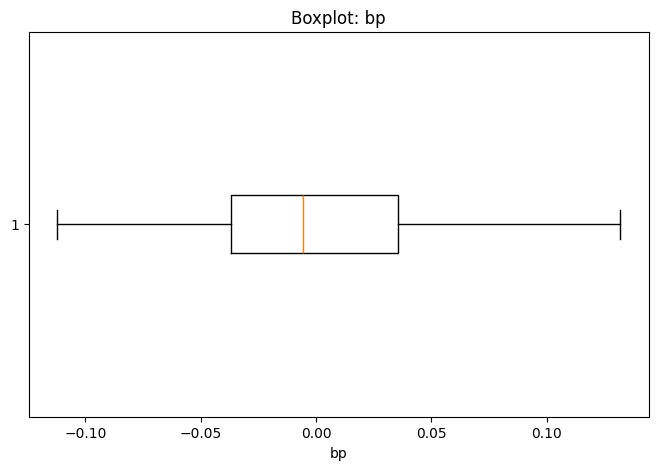

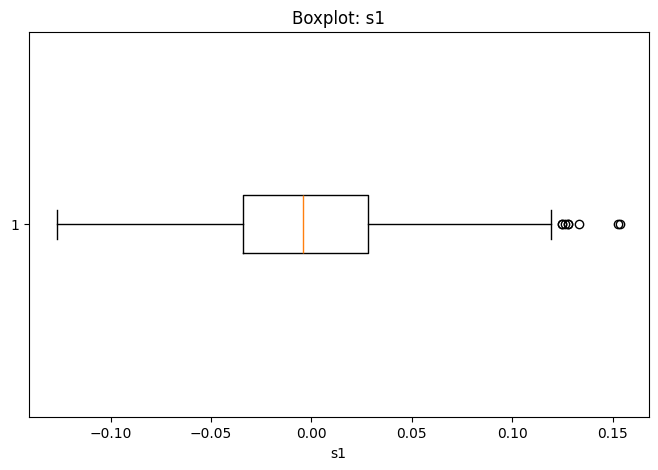

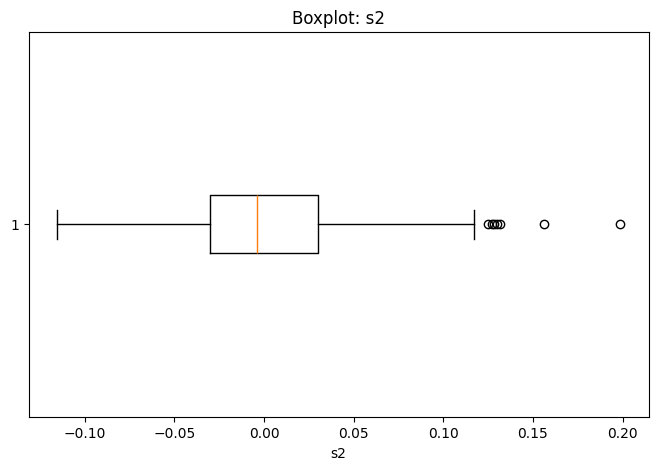

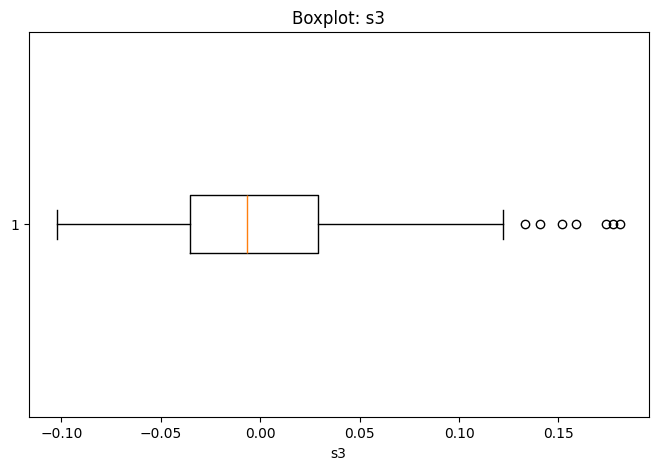

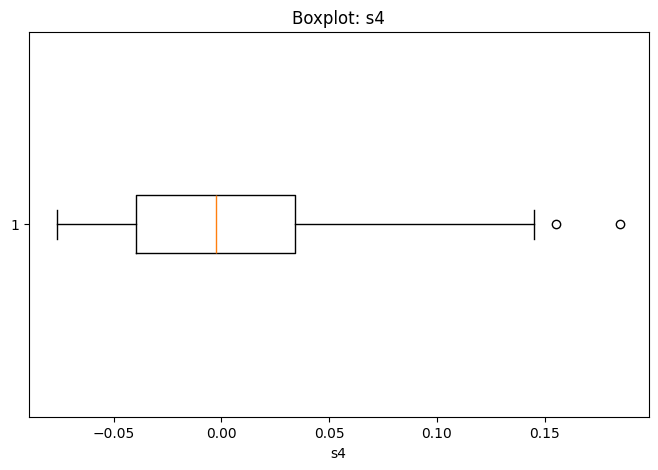

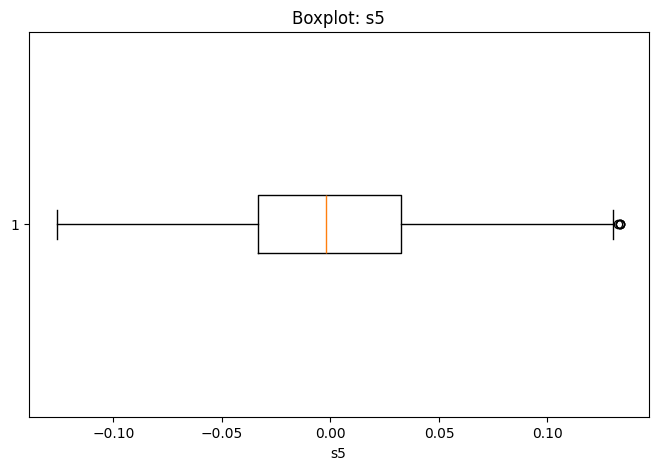

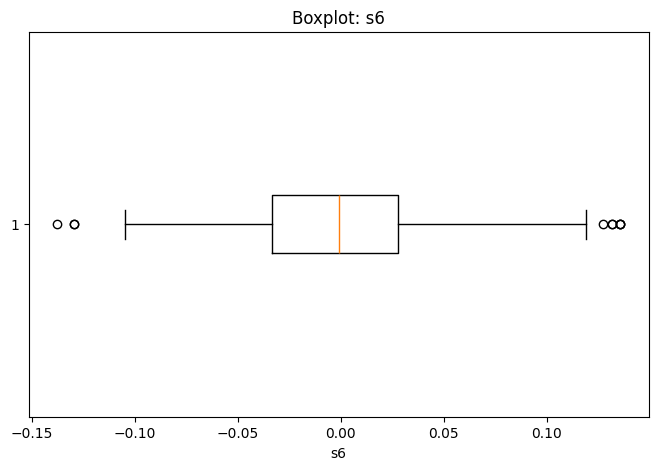

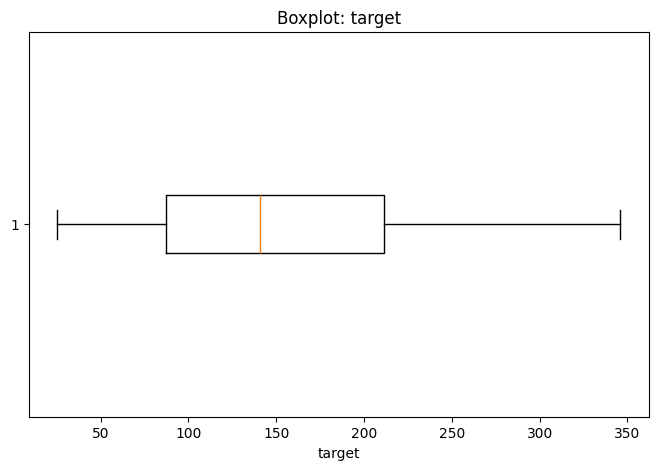

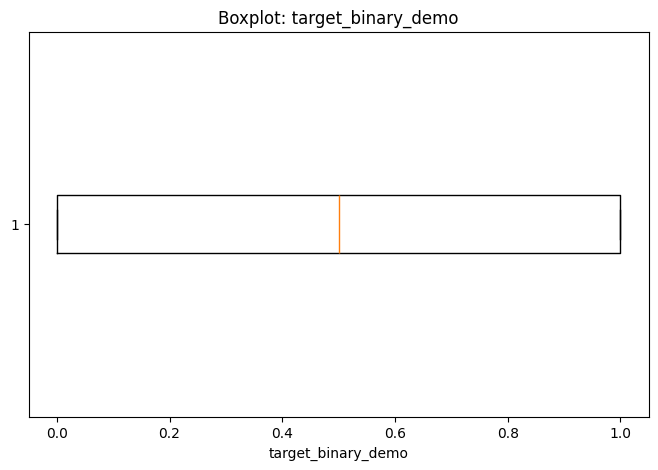

In [5]:
# Univariate analysis: distributions and outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Boxplots (one per column)
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()


Binary-like columns detected: ['sex', 'target_binary_demo']
Using target: sex


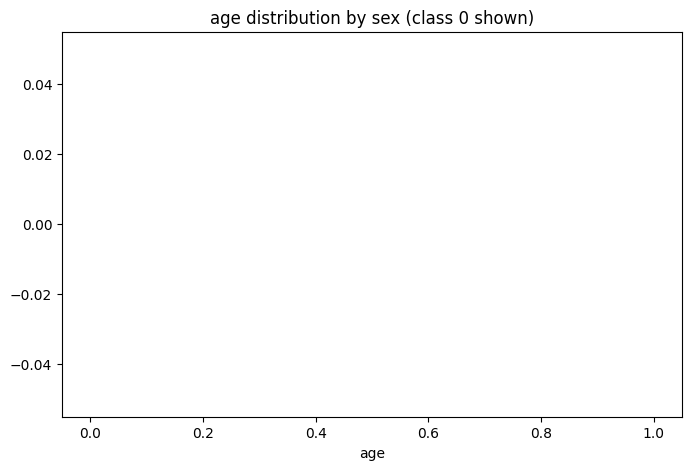

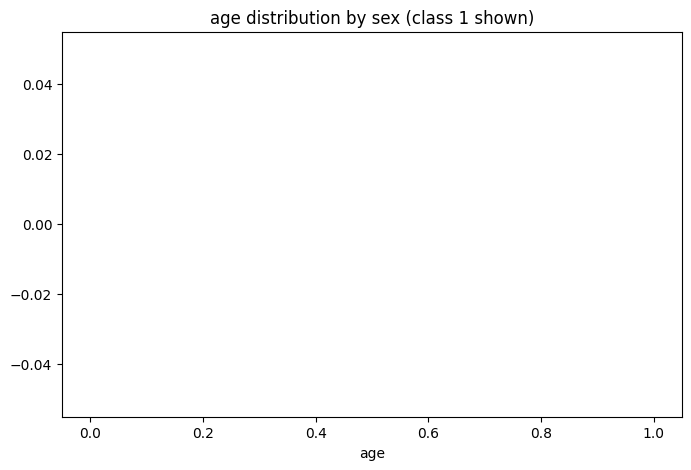

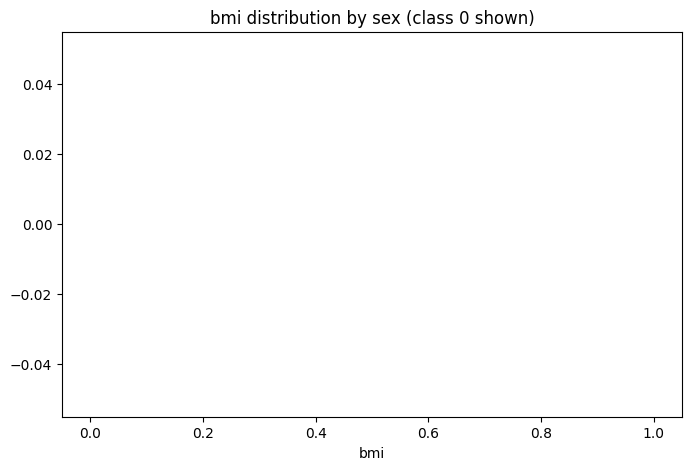

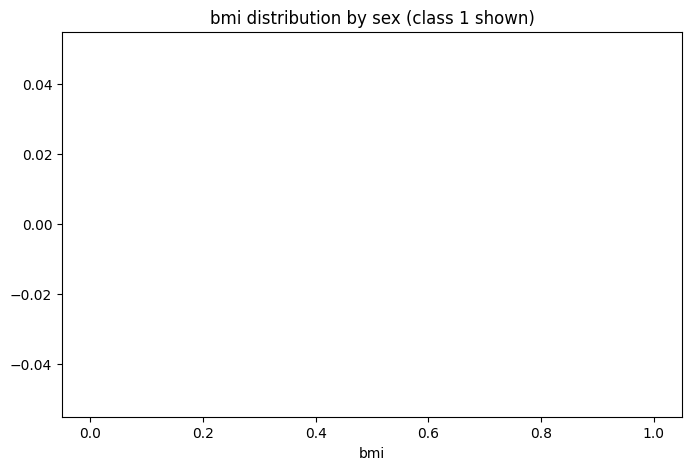

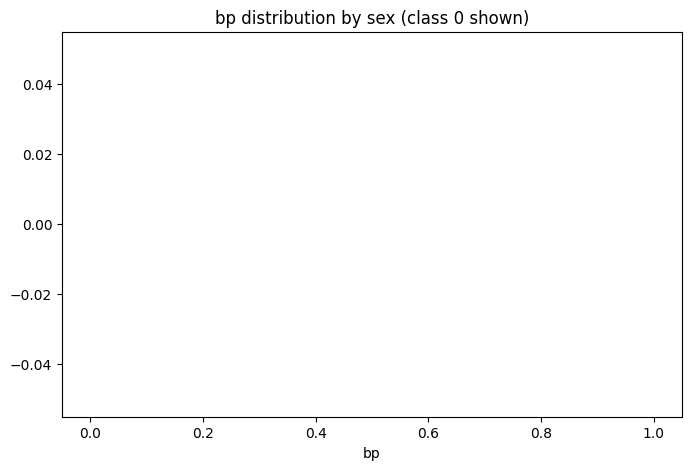

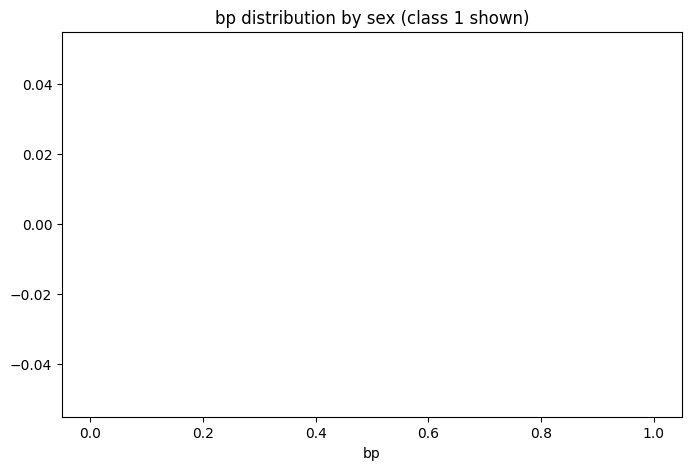

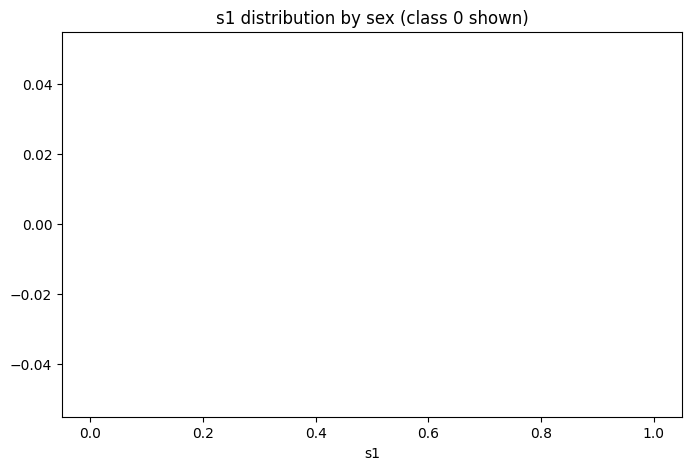

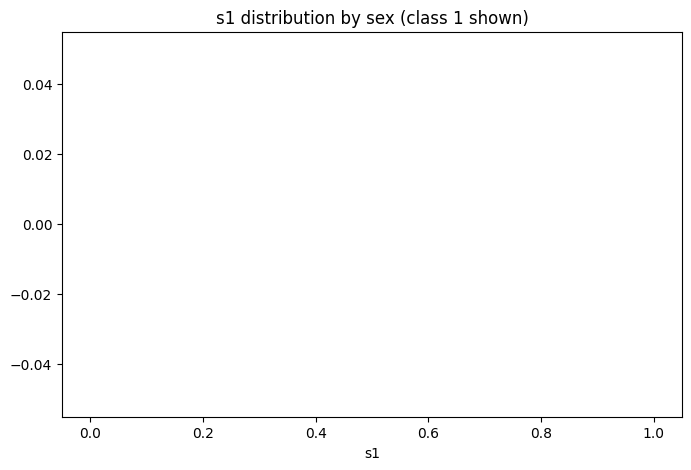

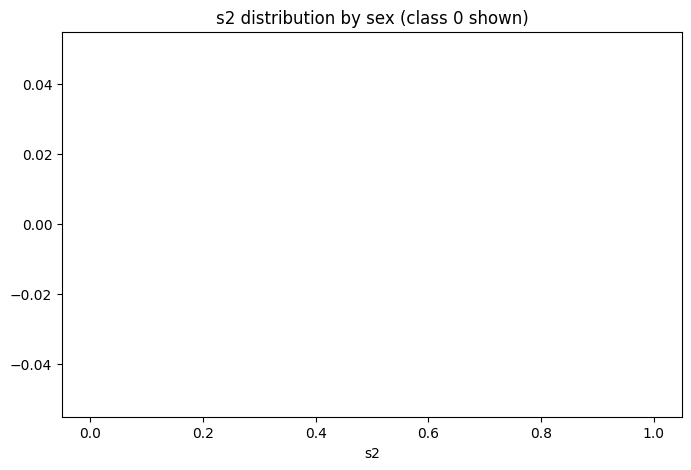

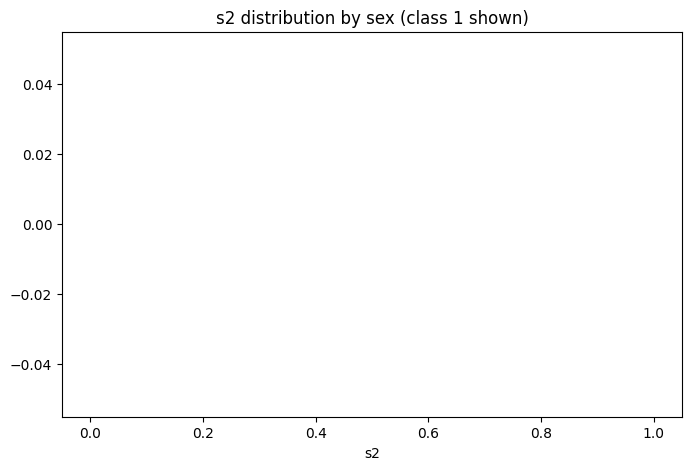

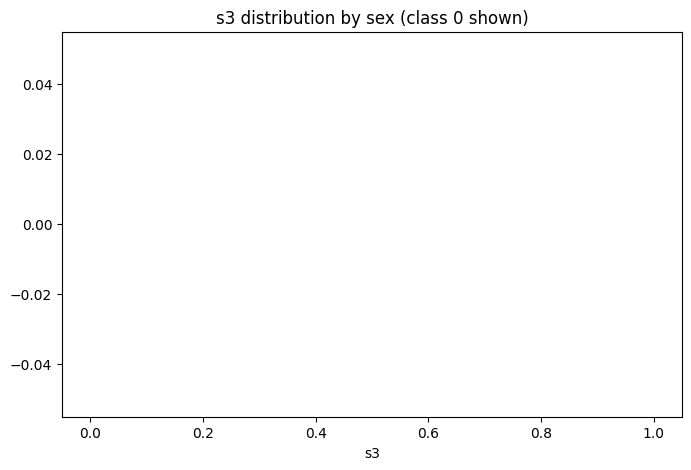

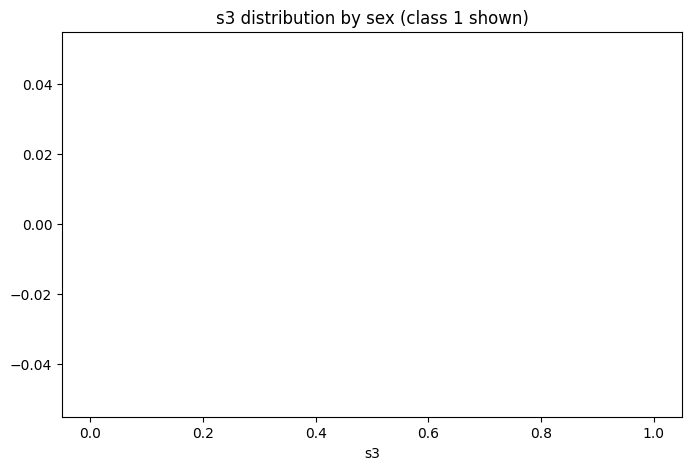

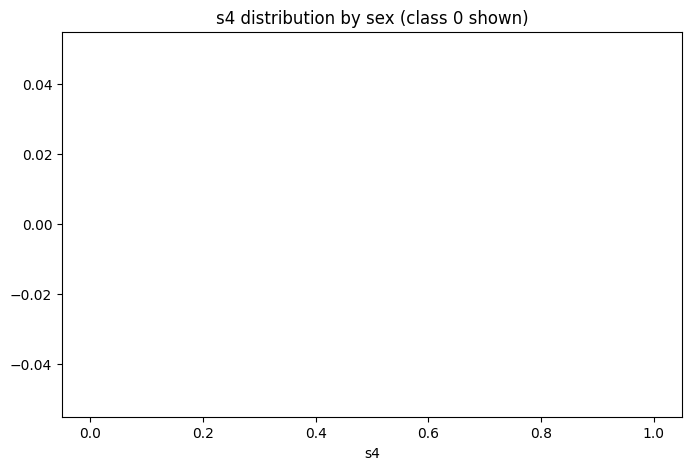

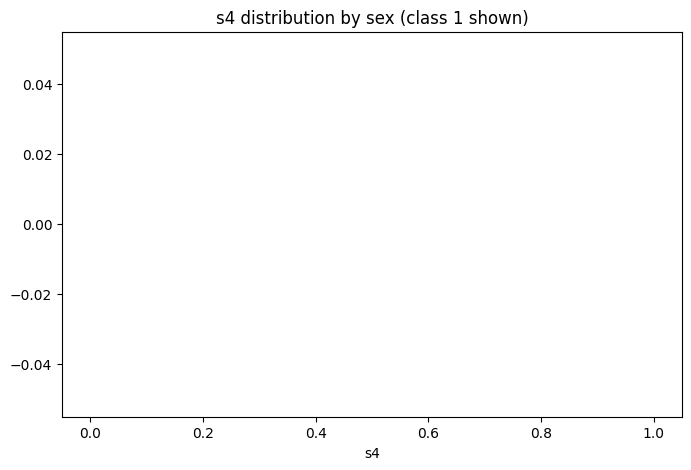

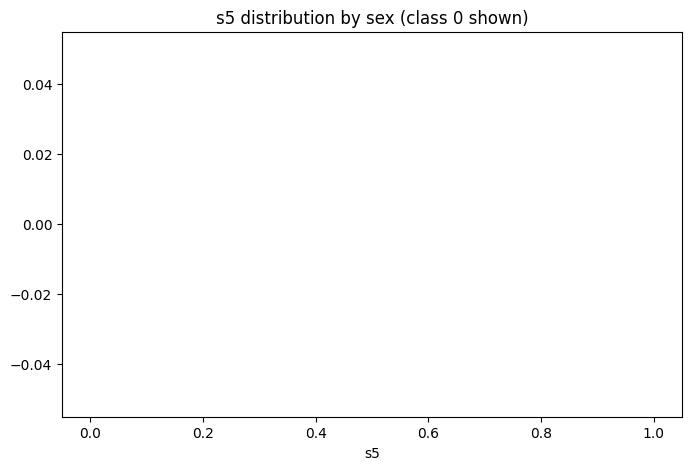

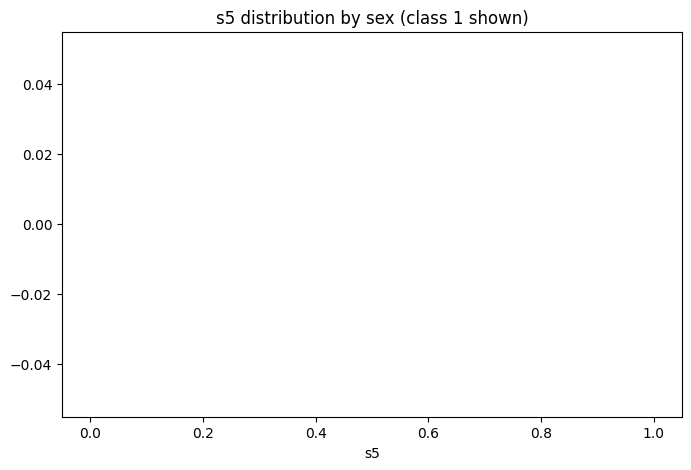

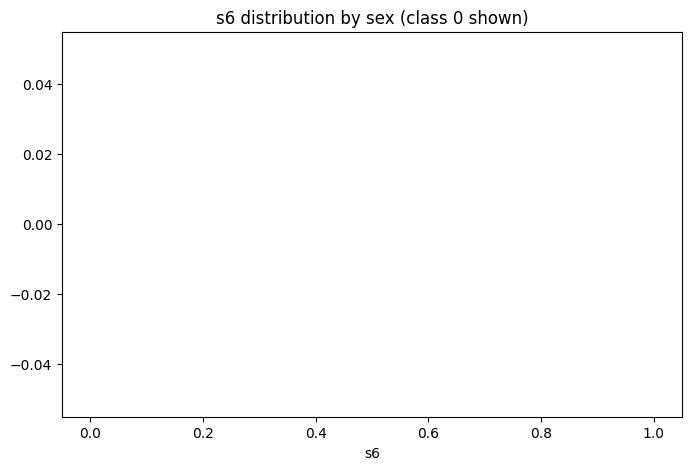

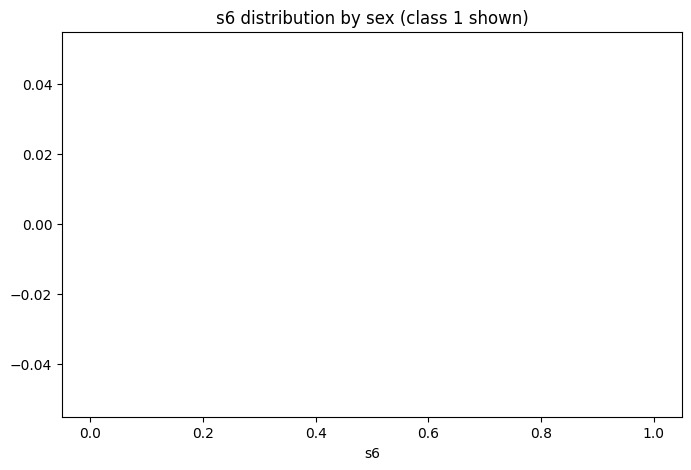

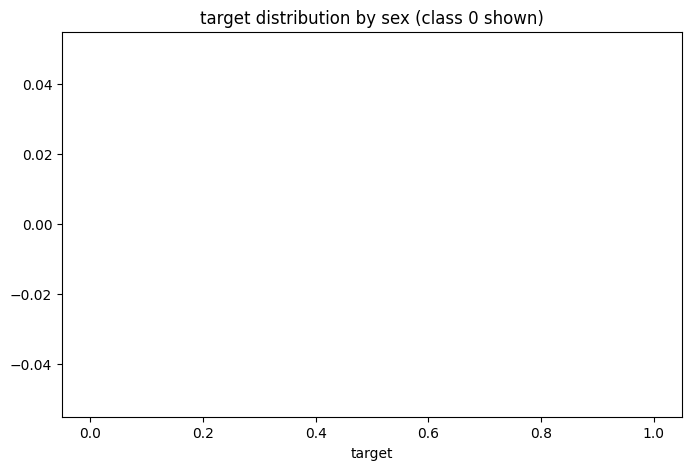

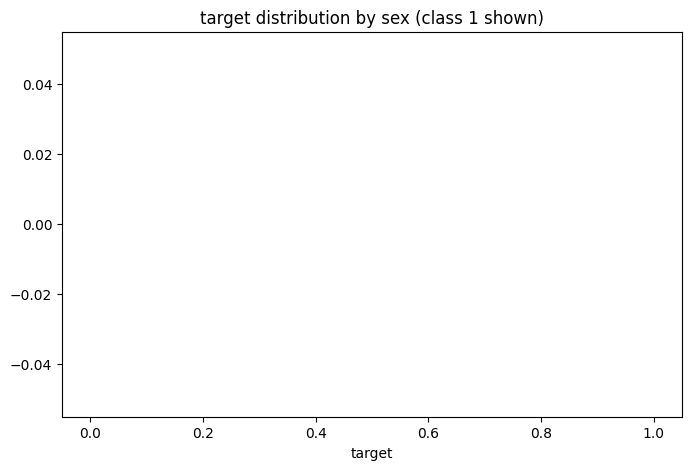

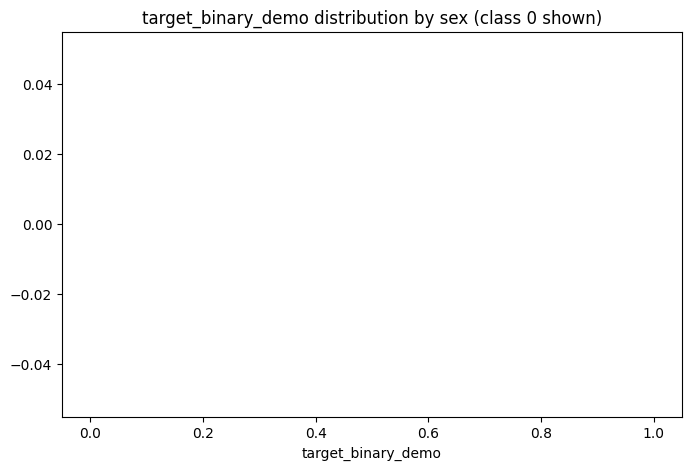

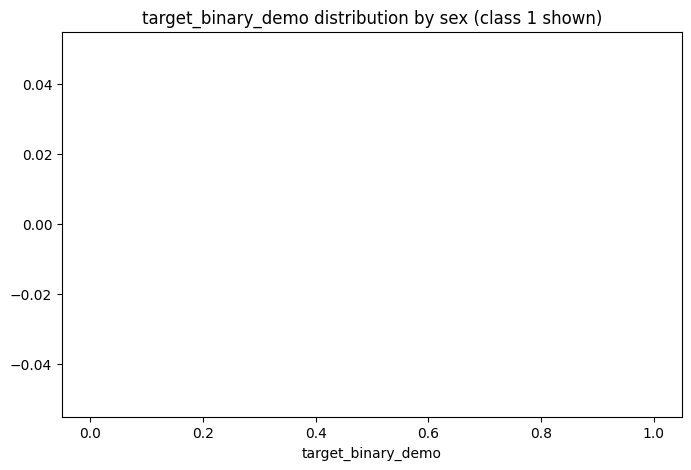

In [6]:
# Bivariate analysis: numeric vs target (if available)
# Try to detect a plausible binary target column
possible_targets = [c for c in df.columns if df[c].nunique() == 2]
print("Binary-like columns detected:", possible_targets)

if possible_targets:
    target = possible_targets[0]
    print("Using target:", target)
    for col in numeric_cols:
        if col == target: 
            continue
        plt.figure()
        # violin-like: overlay histograms per class using separate plots
        vals0 = df[df[target]==0][col].dropna()
        vals1 = df[df[target]==1][col].dropna()
        plt.hist(vals0, bins=30, alpha=0.6)
        plt.title(f"{col} distribution by {target} (class 0 shown)")
        plt.xlabel(col)
        plt.show()

        plt.figure()
        plt.hist(vals1, bins=30, alpha=0.6)
        plt.title(f"{col} distribution by {target} (class 1 shown)")
        plt.xlabel(col)
        plt.show()
else:
    print("No clear binary target found. If you have a target column, please rename it to a binary column before rerunning.")


=== Correlation head (numeric) (shape=(5, 12)) ===


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,target_binary_demo
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889,0.157750
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062,0.004534
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450,0.460628
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482,0.365951
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022,0.160870


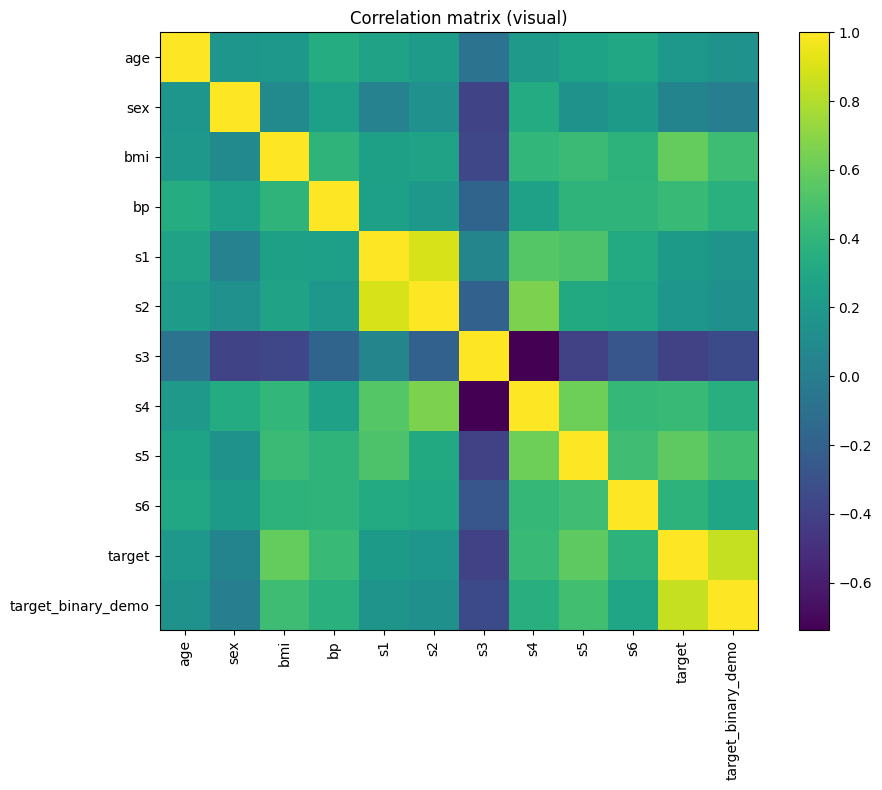

In [7]:
# Correlation matrix and heatmap (Matplotlib only)
corr = df.corr()
show_df("Correlation head (numeric)", corr.head())

# Plot correlation matrix as image
plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation matrix (visual)")
plt.tight_layout()
plt.show()


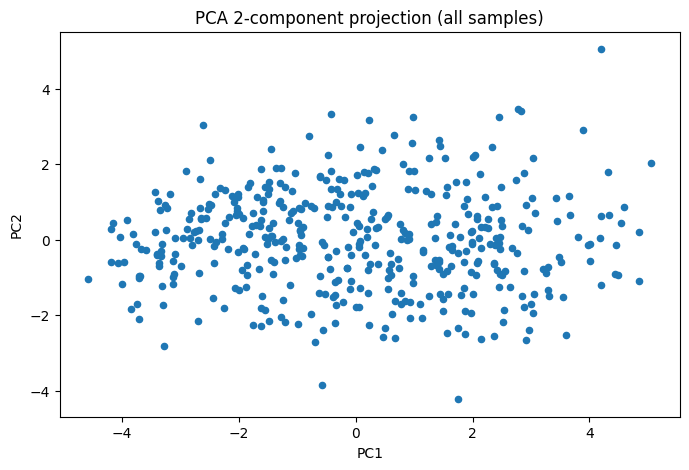

Explained variance ratios (2 components): [0.39608019 0.1444876 ]


In [8]:
# PCA for visual clustering (numeric features only)
X = df.select_dtypes(include=[np.number]).copy()
# Drop target(s) if present
for c in X.columns:
    if X[c].nunique() == 2 and c in df.columns:
        # keep target for coloring but drop from PCA features
        pass

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=20)
plt.title("PCA 2-component projection (all samples)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratios (2 components):", pca.explained_variance_ratio_)


In [9]:
# Detect class imbalance for a binary target (✅ FIXED)
binary_targets = [c for c in df.columns if df[c].nunique() == 2]
if binary_targets:
    t = binary_targets[0]
    counts = df[t].value_counts()
    print("Target class distribution for", t)
    print(counts)
    majority_class = counts.idxmax()
    minority_class = counts.idxmin()
    if counts.min() / counts.max() < 0.5:
        print("Detected imbalance — simple upsampling will be demonstrated.")
        df_major = df[df[t] == majority_class]
        df_minor = df[df[t] == minority_class]
        df_minor_upsampled = resample(df_minor, replace=True, n_samples=len(df_major), random_state=42)
        df_balanced = pd.concat([df_major, df_minor_upsampled])
        print("After upsampling, class distribution:")
        print(df_balanced[t].value_counts())
    else:
        print("No significant imbalance detected.")
else:
    print("No binary target found — skip imbalance handling demo.")

Target class distribution for sex
sex
-0.044642    235
 0.050680    207
Name: count, dtype: int64
No significant imbalance detected.


In [10]:
# Save cleaned dataframe for later modeling (✅ fixed)
out_path = "diabetes_cleaned.csv"   # save in current directory
df.to_csv(out_path, index=False)
print("Saved cleaned data to:", out_path)


Saved cleaned data to: diabetes_cleaned.csv
